# Visualización de datos

In [ ]:
import pandas as pd

datos = pd.read_csv('housing.csv')

In [2]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
datos["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
datos.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

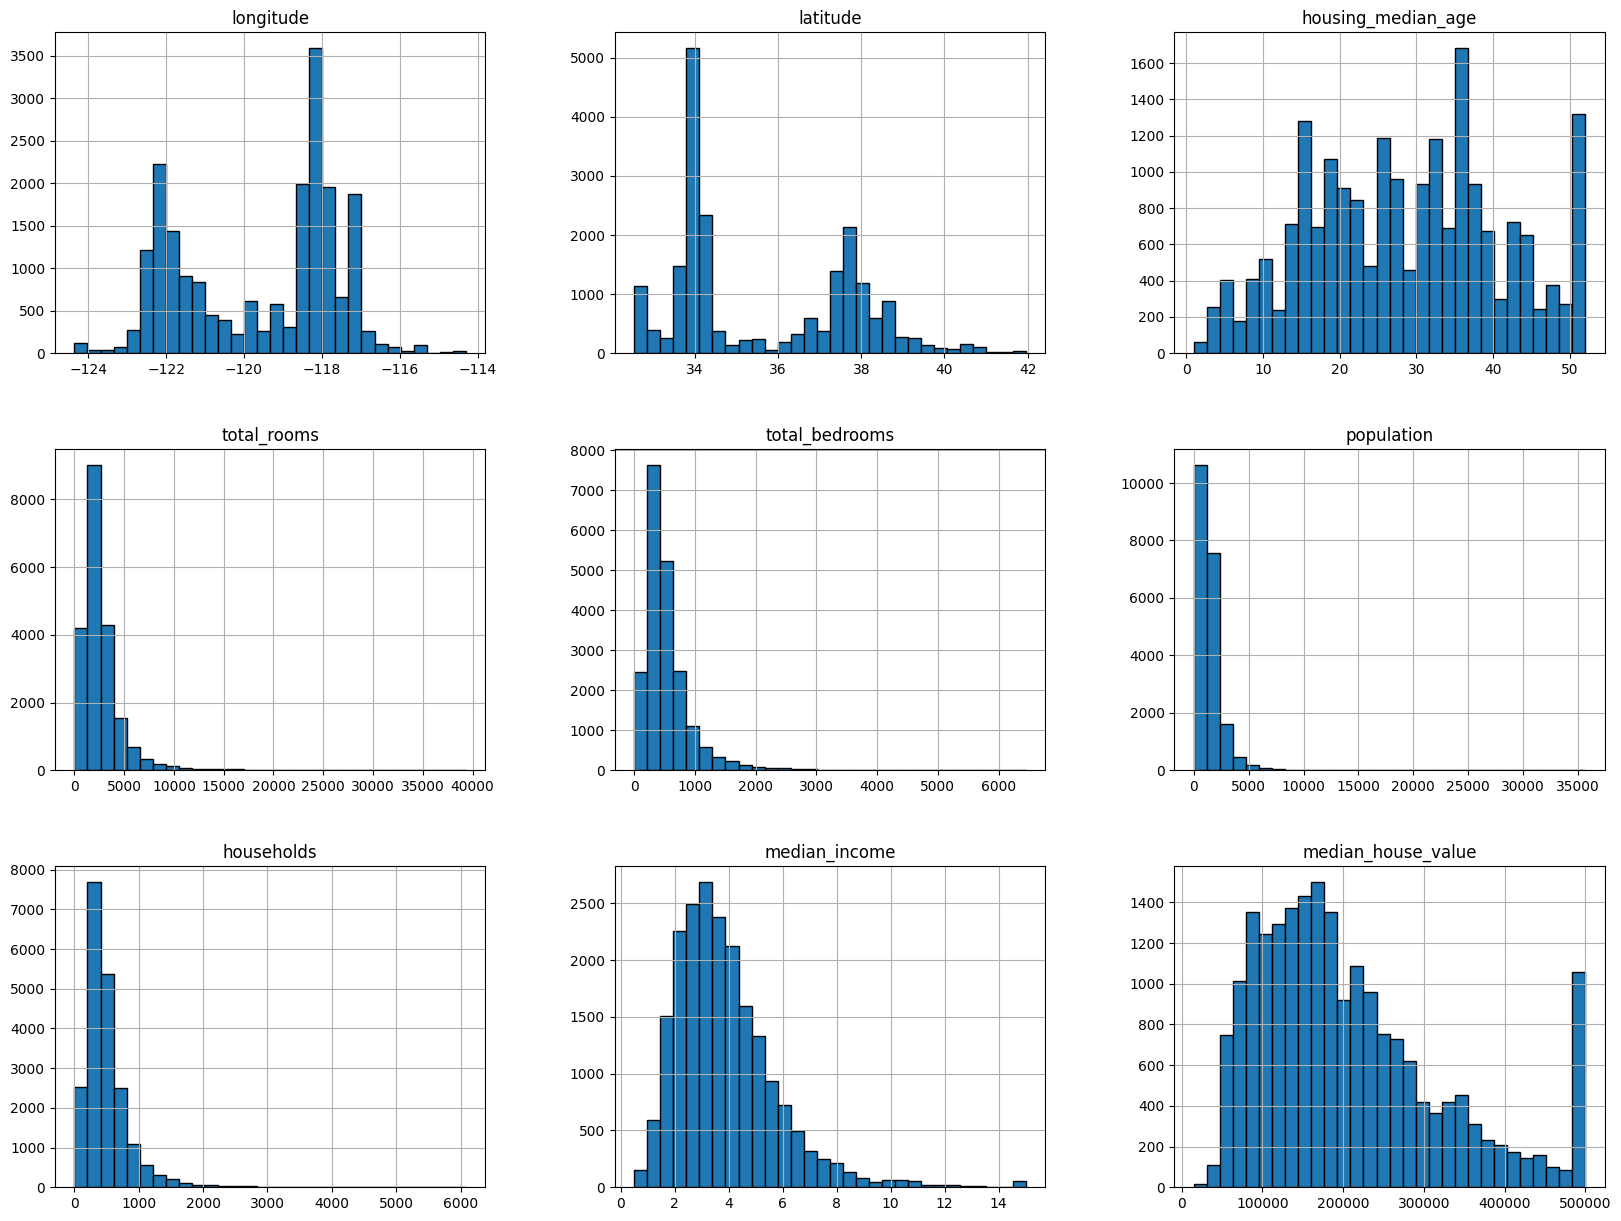

In [7]:
datos.hist(figsize=(20,15), bins=30, edgecolor="black")

<Axes: >

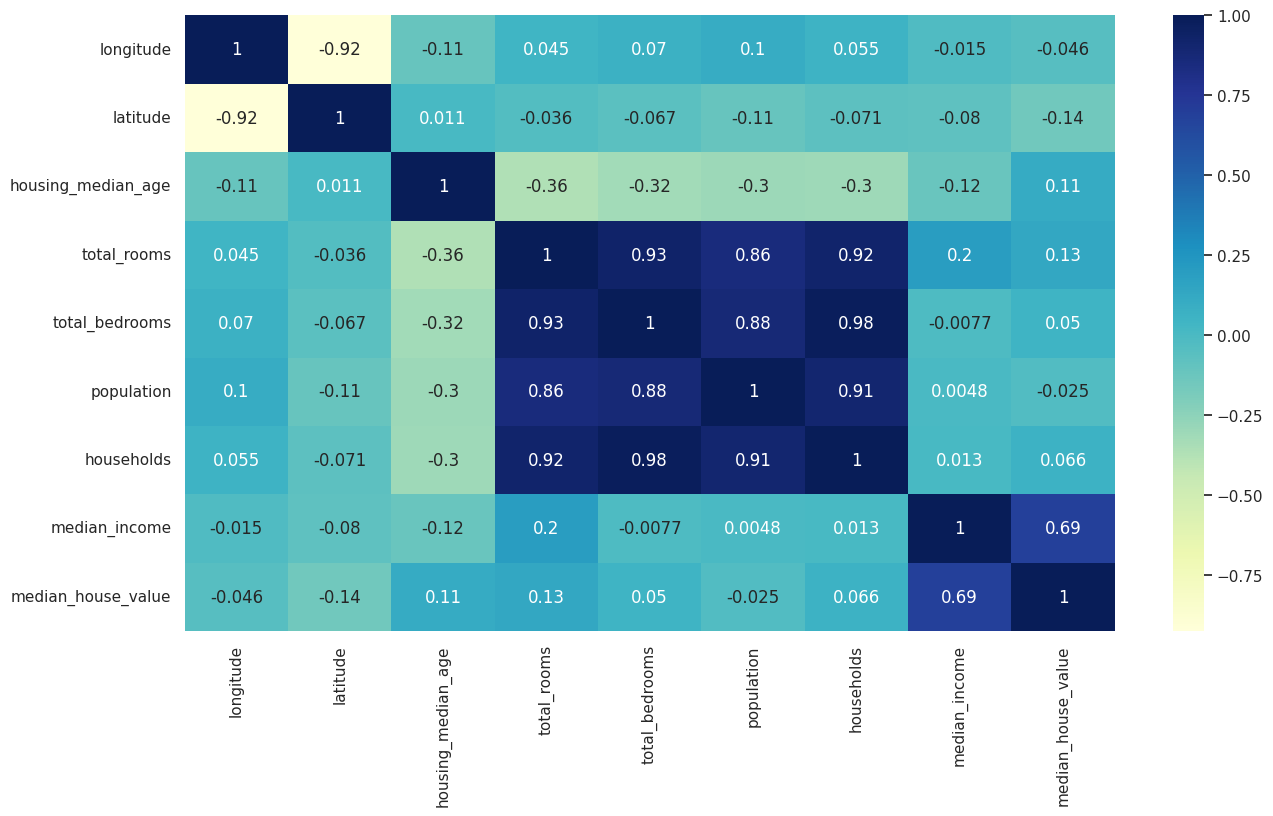

In [15]:
sb.set(rc={"figure.figsize": (15,8)})
sb.heatmap(datos.select_dtypes(include=['number']).corr(), annot=True, cmap="YlGnBu")

In [9]:
datos.select_dtypes(include=['number']).corr()["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


In [11]:
import seaborn as sb

<Axes: xlabel='median_house_value', ylabel='median_income'>

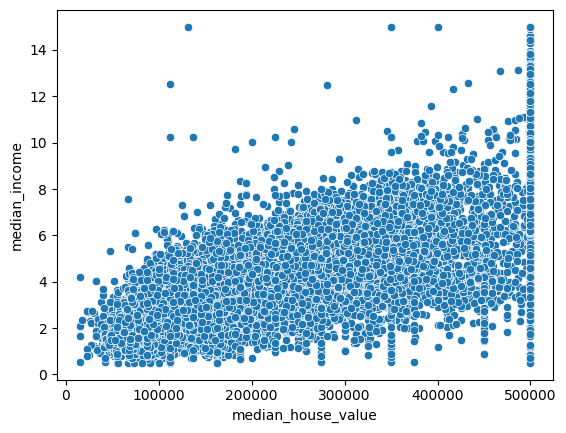

In [13]:
sb.scatterplot(x=datos["median_house_value"], y=datos["median_income"])

In [16]:
datos["bedroom_ratio"] = datos["total_bedrooms"] / datos["total_rooms"]

<Axes: >

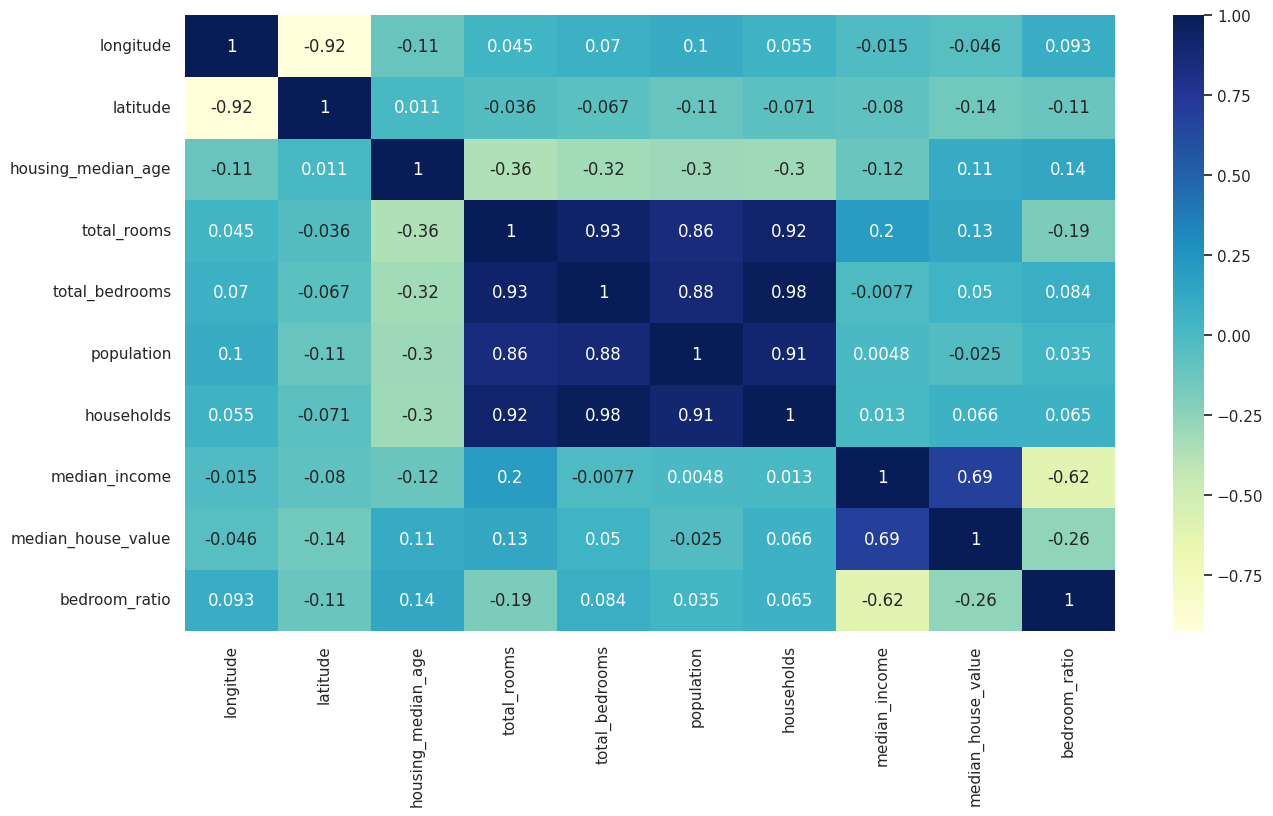

In [17]:
sb.set(rc={"figure.figsize": (15,8)})
sb.heatmap(datos.select_dtypes(include=['number']).corr(), annot=True, cmap="YlGnBu")

# Separar las caracteristicas de la etiqueta

In [36]:
X= datos.drop("median_house_value", axis=1)
y= datos["median_house_value"]

# Separar los datos en 2 partes: Conjunto de enrtrenamiento y uno de pruebas

In [37]:
from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=.2)

In [38]:
from sklearn.linear_model import LinearRegression
modelo=LinearRegression()

In [44]:
modelo.fit(X_ent, y_ent)

LinearRegression()

In [46]:
pre = modelo.predict(X_pru)

In [49]:
com = {"Prediccion":pre, "Valor Real": y_pru}


pd.DataFrame(com)

,Prediccion,Valor Real
10860,214695.204206,262500.0
15250,244002.149704,244700.0
5596,213274.713513,131300.0
2226,296200.814857,187300.0
12469,167152.173923,147900.0
...,...,...
20209,301742.411430,281100.0
4524,135398.218135,151600.0
4913,156626.257644,113300.0
3952,379300.789800,390000.0


# Overfitting sobreajuste

In [50]:
print(modelo.score(X_ent, y_ent))
print(modelo.score(X_pru, y_pru))

0.647196888356127
0.6686629213789874


# Error

In [51]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_pru, pre)

In [52]:
mse

4438248610.334737

In [53]:
rmse = np.sqrt(mse)

In [54]:
rmse

np.float64(66620.18170445602)

# Scaler Escalamiento

In [56]:
datos.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_ent_esc = scaler.fit_transform(X_ent)
X_pru_esc = scaler.transform(X_pru)

In [58]:
X_ent

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,bedroom_ratio,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
4435,-118.21,34.08,39.0,986.0,361.0,1347.0,299.0,2.2907,0.366126,False,False,False,False
1772,-122.36,37.95,38.0,1042.0,289.0,773.0,248.0,2.7714,0.277351,False,False,True,False
4773,-118.34,34.03,48.0,1426.0,331.0,784.0,356.0,1.6581,0.232118,False,False,False,False
5526,-118.41,33.97,37.0,1629.0,275.0,668.0,266.0,6.1333,0.168815,False,False,False,False
5762,-118.29,34.16,31.0,1262.0,338.0,1019.0,332.0,3.7083,0.267829,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13480,-117.37,34.10,44.0,2087.0,447.0,1270.0,423.0,2.3889,0.214183,True,False,False,False
8748,-118.36,33.82,36.0,1784.0,311.0,901.0,293.0,6.2247,0.174327,False,False,False,False
15191,-117.05,33.02,18.0,917.0,121.0,388.0,131.0,6.3517,0.131952,False,False,False,False
4627,-118.31,34.07,26.0,5062.0,2055.0,4533.0,1822.0,2.3105,0.405966,False,False,False,False


In [59]:
pd.DataFrame(X_ent_esc)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.678102,-0.723702,0.825674,-0.756258,-0.418293,-0.065883,-0.523700,-0.831653,2.631298,-0.678670,-0.017404,-0.349457,-0.386808
1,-1.394852,1.087779,0.746124,-0.730507,-0.590533,-0.572688,-0.657458,-0.578762,1.105285,-0.678670,-0.017404,2.861581,-0.386808
2,0.613166,-0.747106,1.541620,-0.553935,-0.490060,-0.562976,-0.374205,-1.164457,0.327733,-0.678670,-0.017404,-0.349457,-0.386808
3,0.578200,-0.775191,0.666575,-0.460591,-0.624024,-0.665397,-0.610249,1.189898,-0.760424,-0.678670,-0.017404,-0.349457,-0.386808
4,0.638141,-0.686255,0.189277,-0.629346,-0.473314,-0.355486,-0.437150,-0.085869,0.941597,-0.678670,-0.017404,-0.349457,-0.386808
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,1.097687,-0.714340,1.223422,-0.249992,-0.212561,-0.133869,-0.198484,-0.779991,0.019438,1.473471,-0.017404,-0.349457,-0.386808
16508,0.603176,-0.845404,0.587025,-0.389319,-0.537904,-0.459673,-0.539436,1.237983,-0.665671,-0.678670,-0.017404,-0.349457,-0.386808
16509,1.257530,-1.219870,-0.844868,-0.787985,-0.992427,-0.912619,-0.964314,1.304796,-1.394093,-0.678670,-0.017404,-0.349457,-0.386808
16510,0.628151,-0.728383,-0.208471,1.117982,3.634138,2.747153,3.470683,-0.821237,3.316143,-0.678670,-0.017404,-0.349457,-0.386808
